In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('data/titanic_clean.csv')

In [5]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
874,1,2,female,28.0,1,0,24.0000,C
663,0,3,male,36.0,0,0,7.4958,S
837,0,3,male,28.0,0,0,8.0500,S
378,0,3,male,20.0,0,0,4.0125,C
28,1,3,female,28.0,0,0,7.8792,Q


In [6]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

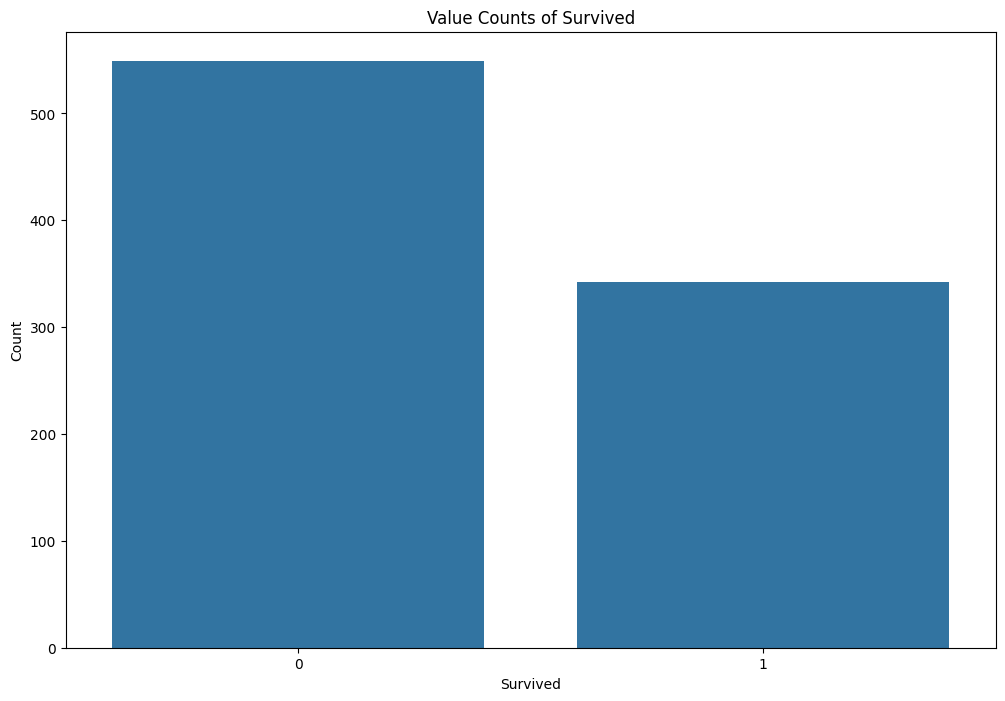

In [7]:
# total de sobrevivientes 

plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [8]:
# calcular tasa de supervivencia
survival_rate = df['Survived'].mean()

print(f'Tasa de supervivencia: {survival_rate:.2%}')

Tasa de supervivencia: 38.38%


Tabla de supervivencia por clase:


Survived,No sobrevivieron,Sobrevivieron,Tasa no sobrevivieron (%),Tasa sobrevivieron (%)
Pclass,,,,
1,80,136,37.04,62.96
2,97,87,52.72,47.28
3,372,119,75.76,24.24


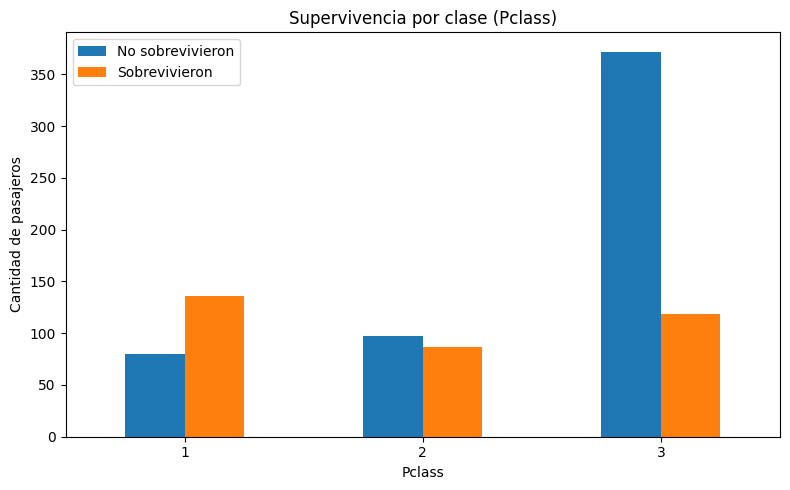

In [11]:
# Tabla: cantidad de pasajeros por Pclass y Survived

tabla = (
    df.groupby(["Pclass", "Survived"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No sobrevivieron", 1: "Sobrevivieron"})
)

# Añadir tasas (porcentaje dentro de cada clase)
total_por_clase = tabla["No sobrevivieron"] + tabla["Sobrevivieron"]
tabla["Tasa no sobrevivieron (%)"] = (tabla["No sobrevivieron"] / total_por_clase * 100).round(2)
tabla["Tasa sobrevivieron (%)"] = (tabla["Sobrevivieron"] / total_por_clase * 100).round(2)

print("Tabla de supervivencia por clase:")
display(tabla)

# Gráfica de barras (solo conteos)
tabla[["No sobrevivieron", "Sobrevivieron"]].plot(kind="bar", figsize=(8, 5))
plt.title("Supervivencia por clase (Pclass)")
plt.xlabel("Pclass")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

Tabla de supervivencia por embarque:


Survived,No sobrevivieron,Sobrevivieron,Tasa no sobrevivieron (%),Tasa sobrevivieron (%)
Embarked,,,,
C,75,93,44.64,55.36
Q,47,30,61.04,38.96
S,427,219,66.10,33.90


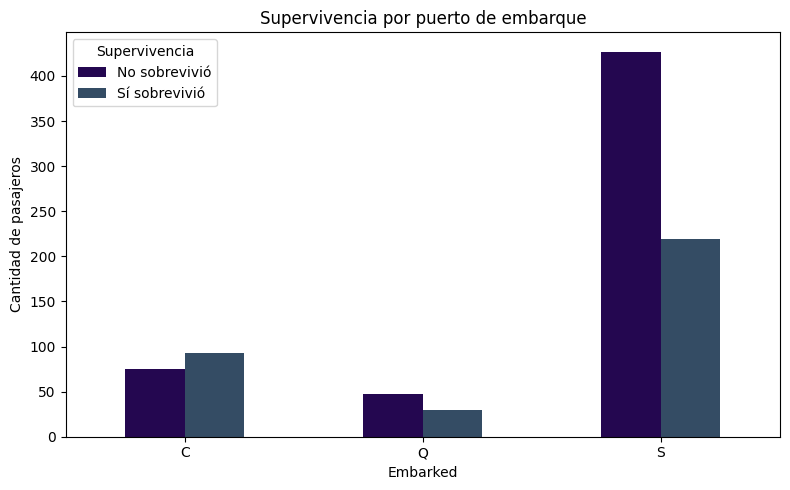

In [12]:
# Supervivencia por embarque (conteo + tasas)

tabla_embarque = (
    df.groupby(["Embarked", "Survived"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "No sobrevivieron", 1: "Sobrevivieron"})
)

# Añadir tasas (porcentaje dentro de cada puerto de embarque)
total_por_embarque = tabla_embarque["No sobrevivieron"] + tabla_embarque["Sobrevivieron"]
tabla_embarque["Tasa no sobrevivieron (%)"] = (tabla_embarque["No sobrevivieron"] / total_por_embarque * 100).round(2)
tabla_embarque["Tasa sobrevivieron (%)"] = (tabla_embarque["Sobrevivieron"] / total_por_embarque * 100).round(2)

print("Tabla de supervivencia por embarque:")
display(tabla_embarque)

# Gráfica de barras (solo conteos)
tabla_embarque[["No sobrevivieron", "Sobrevivieron"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=['#240750', '#344C64']
)
plt.title("Supervivencia por puerto de embarque")
plt.xlabel("Embarked")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)
plt.legend(title="Supervivencia", labels=["No sobrevivió", "Sí sobrevivió"])
plt.tight_layout()
plt.show()

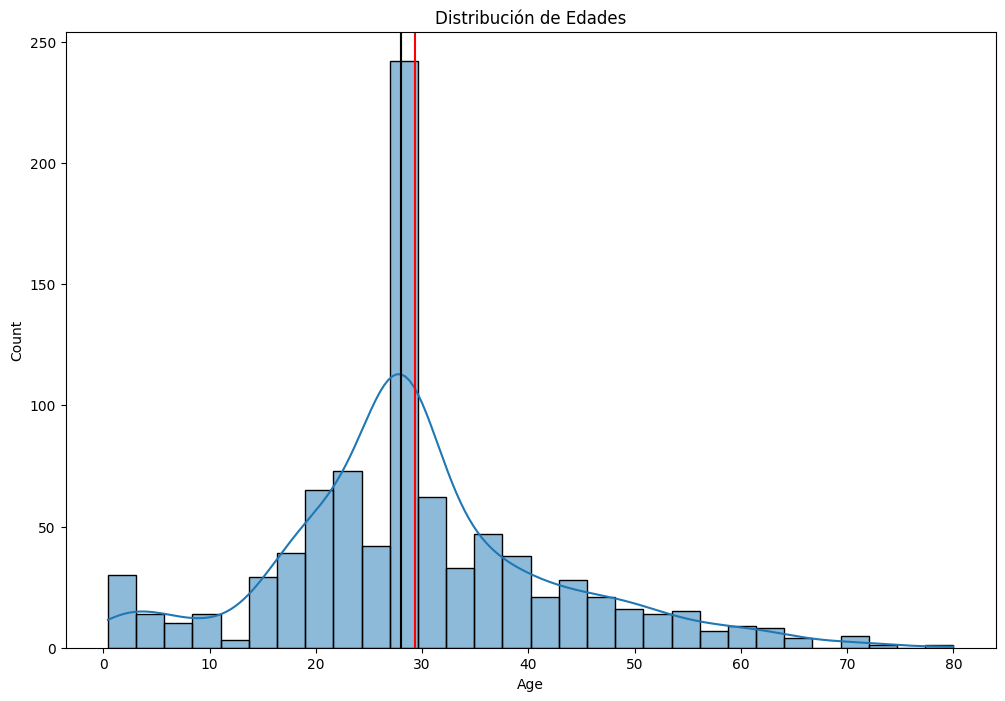

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0
Tabla de edades:


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [14]:
#distribución por edades 

plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

# Tabla de edades
tabla_edades = df[['Age']].dropna().reset_index(drop=True)
print("Tabla de edades:")
display(tabla_edades)

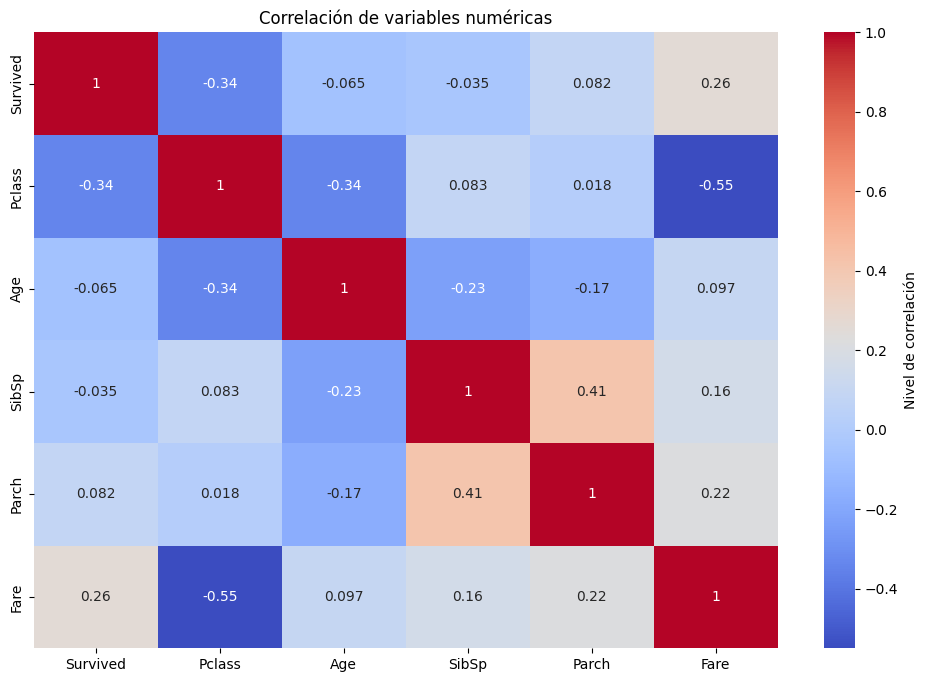

In [15]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

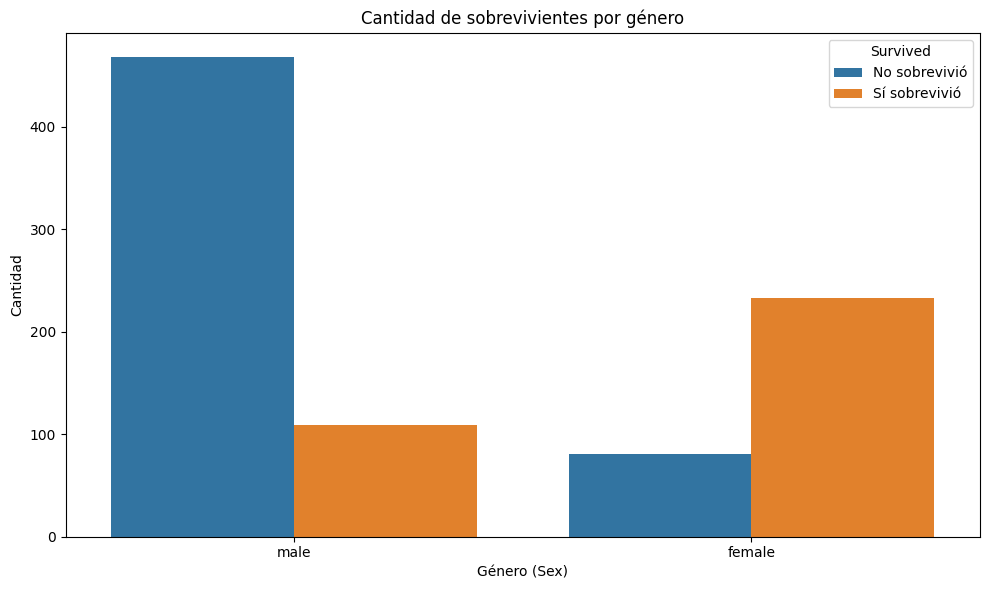

In [ ]:
# Cantidad de sobrevivientes por género (Sex)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Cantidad de sobrevivientes por género')
plt.xlabel('Género (Sex)')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No sobrevivió', 'Sí sobrevivió'])
plt.tight_layout()
plt.show()

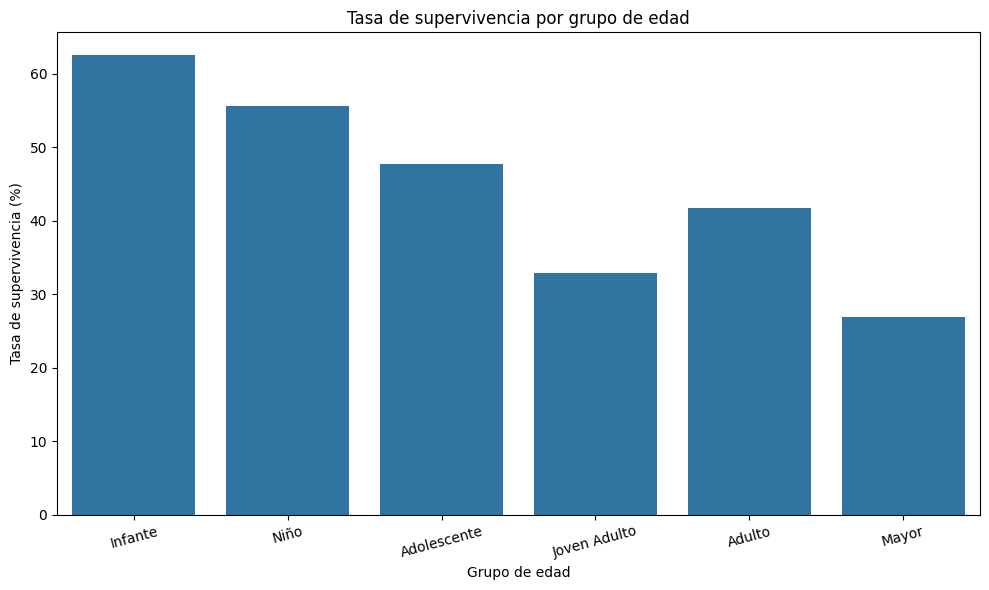

In [ ]:
# Tasa de supervivencia por grupo de edad
bins = [0, 2, 12, 17, 29, 59, 120]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

tasa_por_edad = (
    df.groupby('AgeGroup', observed=False)['Survived']
      .mean()
      .mul(100)
      .reset_index(name='TasaSupervivencia')
)

plt.figure(figsize=(10, 6))
sns.barplot(data=tasa_por_edad, x='AgeGroup', y='TasaSupervivencia')
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

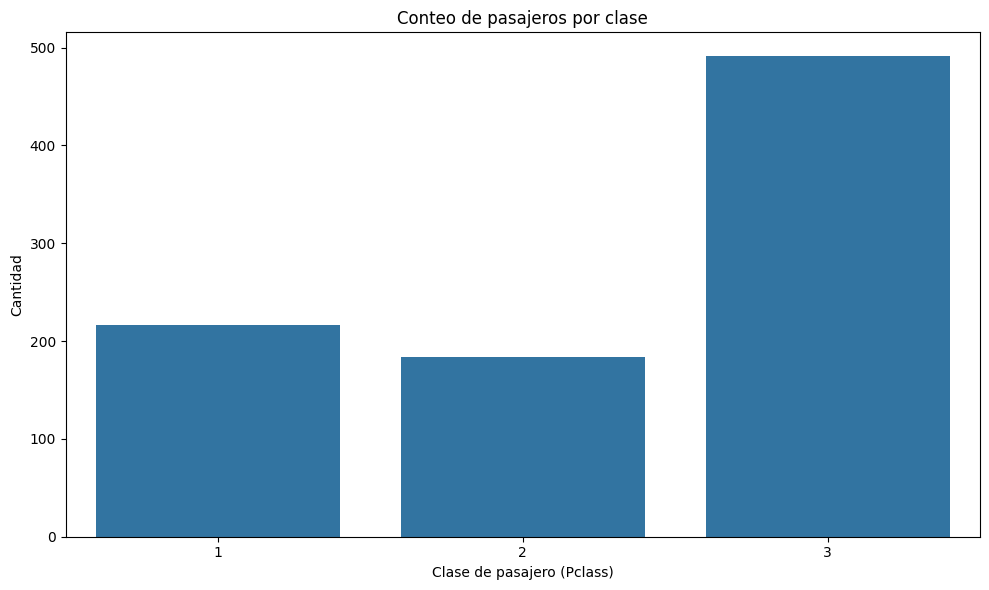

In [ ]:
# Conteo de pasajeros en cada clase (Pclass)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass')
plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase de pasajero (Pclass)')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

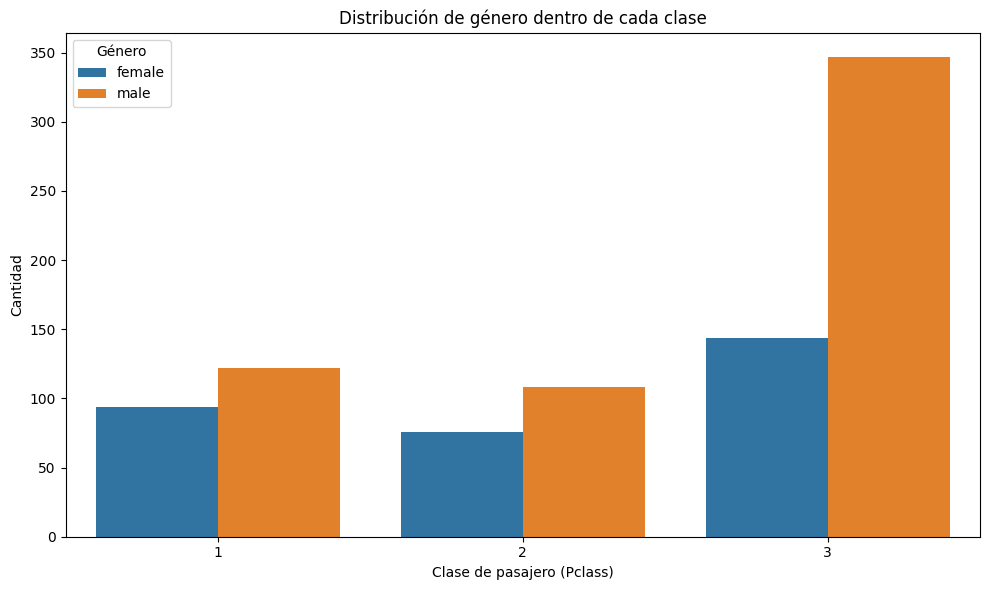

In [22]:
# Distribución de género dentro de cada clase de pasajero (Pclass)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Sex')
plt.title('Distribución de género dentro de cada clase')
plt.xlabel('Clase de pasajero (Pclass)')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

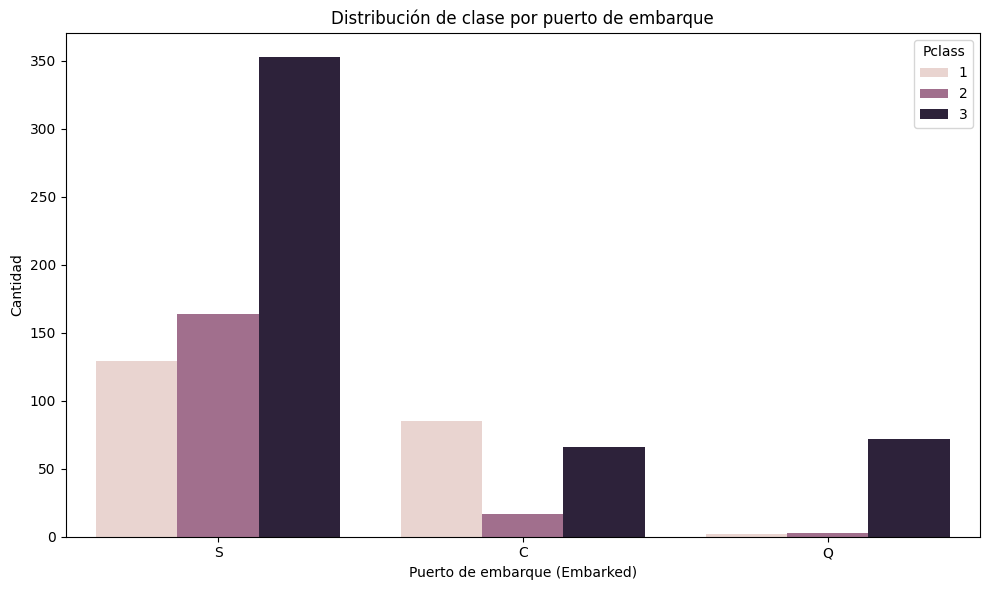

In [23]:
#  Distribución de clase de pasajero por puerto de embarque (Embarked)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Embarked', hue='Pclass')
plt.title('Distribución de clase por puerto de embarque')
plt.xlabel('Puerto de embarque (Embarked)')
plt.ylabel('Cantidad')
plt.legend(title='Pclass')
plt.tight_layout()
plt.show()

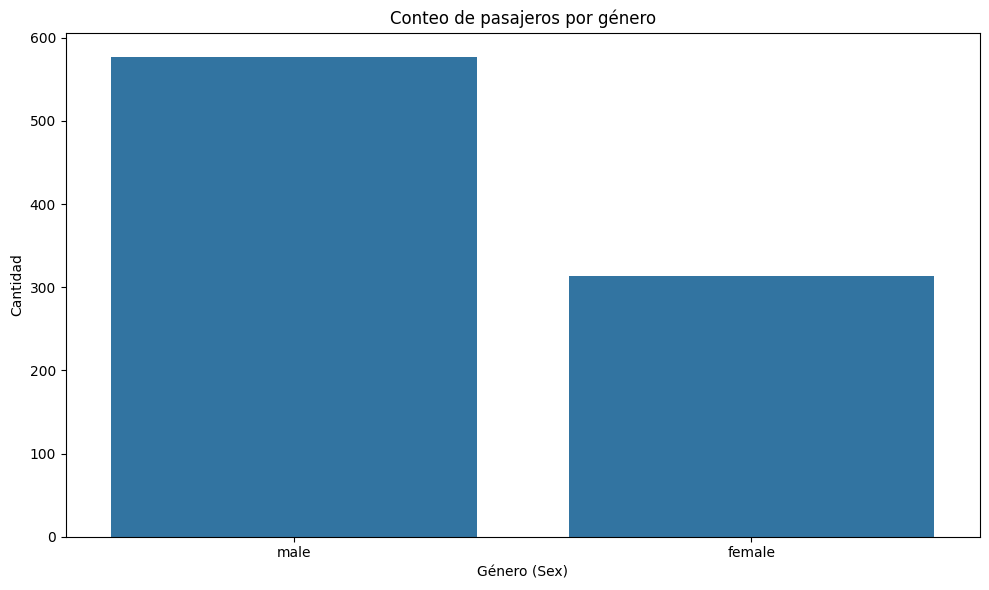

In [24]:
# 9) Conteo de pasajeros por género (Sex)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex')
plt.title('Conteo de pasajeros por género')
plt.xlabel('Género (Sex)')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

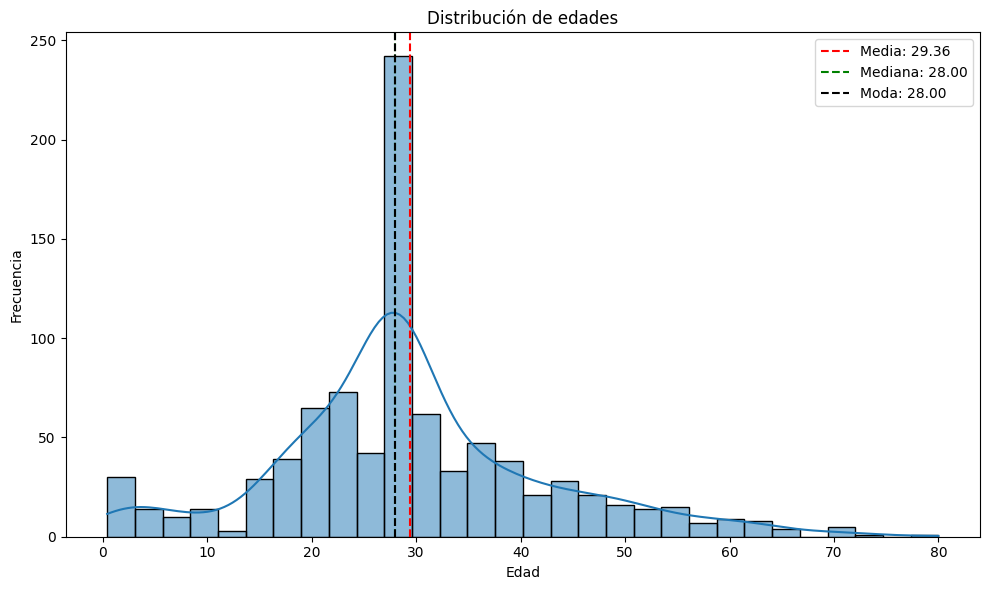

In [25]:
# Distribución de edades con media, mediana y moda
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()[0]

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', kde=True)
plt.axvline(age_mean, color='red', linestyle='--', label=f'Media: {age_mean:.2f}')
plt.axvline(age_median, color='green', linestyle='--', label=f'Mediana: {age_median:.2f}')
plt.axvline(age_mode, color='black', linestyle='--', label=f'Moda: {age_mode:.2f}')
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

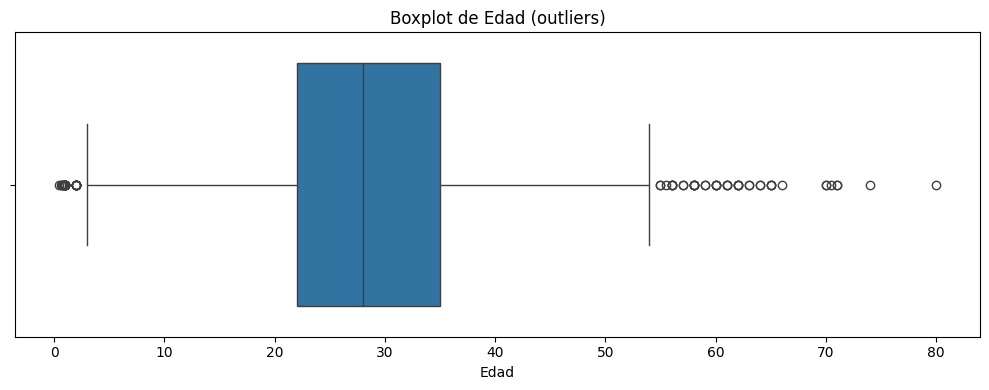

In [26]:
# Boxplot de edad para visualizar outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Age')
plt.title('Boxplot de Edad (outliers)')
plt.xlabel('Edad')
plt.tight_layout()
plt.show()

In [27]:
# Valores máximo y mínimo de Fare
fare_max = df['Fare'].max()
fare_min = df['Fare'].min()

print(f"Tarifa máxima (Fare): {fare_max}")
print(f"Tarifa mínima (Fare): {fare_min}")

Tarifa máxima (Fare): 512.3292
Tarifa mínima (Fare): 0.0


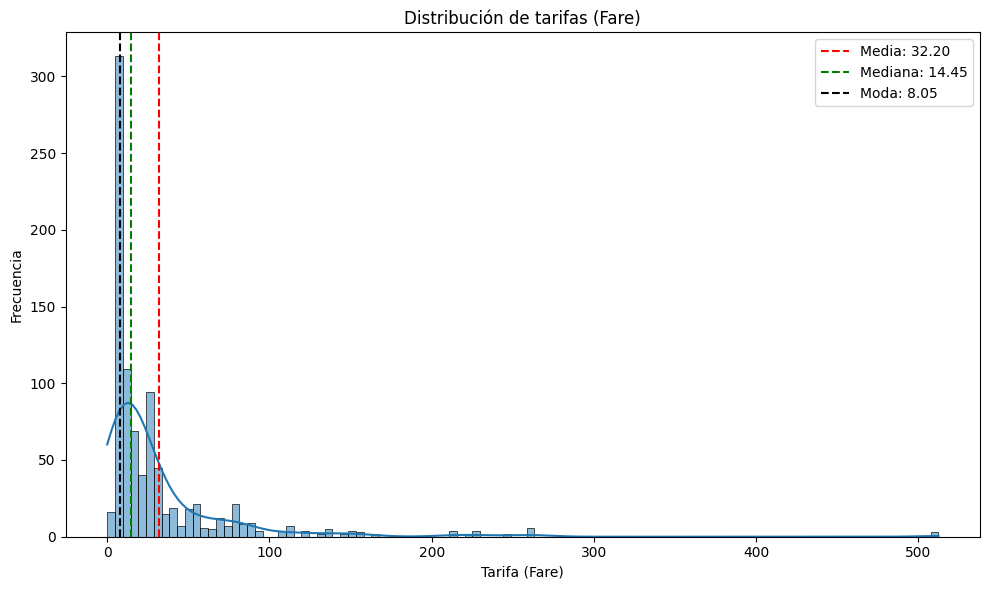

In [28]:
# Distribución de Fare con media, mediana y moda
fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()
fare_mode = df['Fare'].mode()[0]

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fare', kde=True)
plt.axvline(fare_mean, color='red', linestyle='--', label=f'Media: {fare_mean:.2f}')
plt.axvline(fare_median, color='green', linestyle='--', label=f'Mediana: {fare_median:.2f}')
plt.axvline(fare_mode, color='black', linestyle='--', label=f'Moda: {fare_mode:.2f}')
plt.title('Distribución de tarifas (Fare)')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

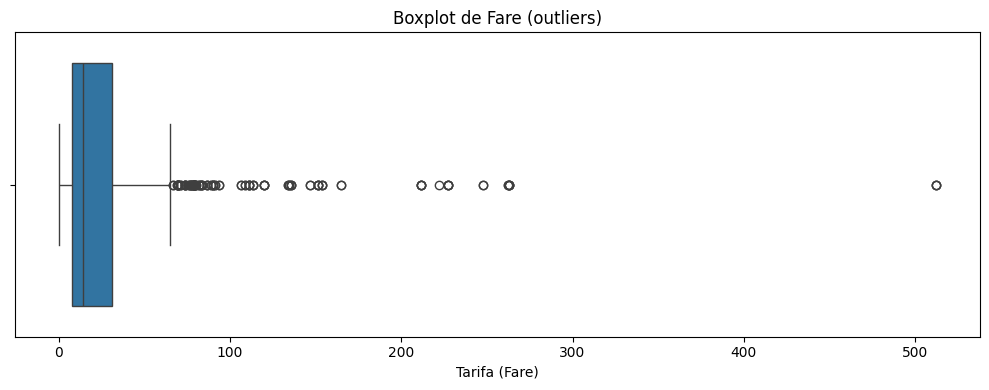

In [29]:
# Boxplot de Fare para visualizar outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Fare')
plt.title('Boxplot de Fare (outliers)')
plt.xlabel('Tarifa (Fare)')
plt.tight_layout()
plt.show()

In [30]:
# Pasajeros que pagaron 0 en Fare
pasajeros_fare_cero = df[df['Fare'] == 0]
print(f"Cantidad de pasajeros con Fare = 0: {len(pasajeros_fare_cero)}")
display(pasajeros_fare_cero)

Cantidad de pasajeros con Fare = 0: 15


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
179,0,3,male,36.0,0,0,0.0,S,Adulto
263,0,1,male,40.0,0,0,0.0,S,Adulto
271,1,3,male,25.0,0,0,0.0,S,Joven Adulto
277,0,2,male,28.0,0,0,0.0,S,Joven Adulto
302,0,3,male,19.0,0,0,0.0,S,Joven Adulto
413,0,2,male,28.0,0,0,0.0,S,Joven Adulto
466,0,2,male,28.0,0,0,0.0,S,Joven Adulto
481,0,2,male,28.0,0,0,0.0,S,Joven Adulto
597,0,3,male,49.0,0,0,0.0,S,Adulto
633,0,1,male,28.0,0,0,0.0,S,Joven Adulto


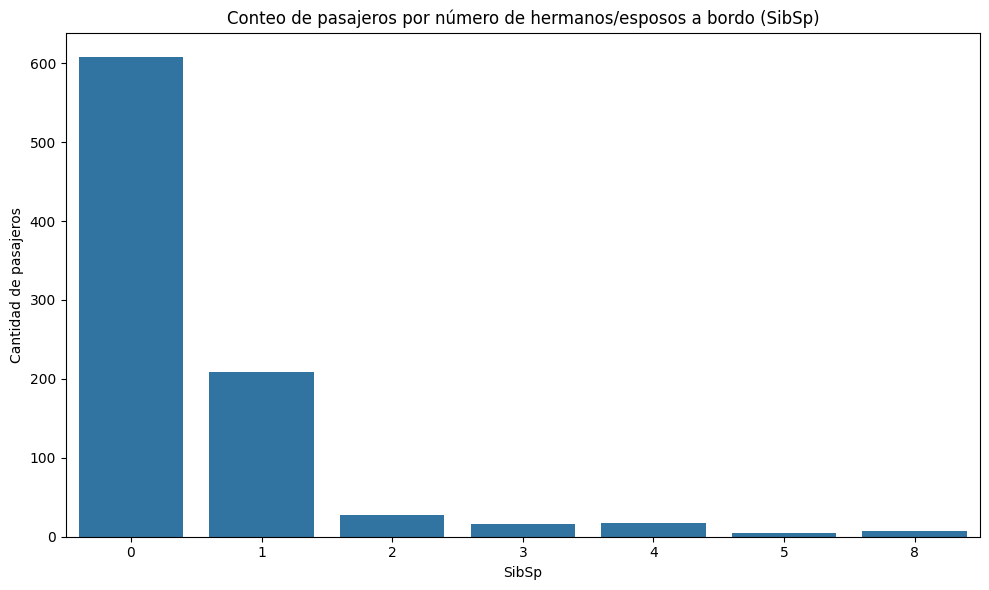

In [31]:
# Conteo de pasajeros por SibSp
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SibSp')
plt.title('Conteo de pasajeros por número de hermanos/esposos a bordo (SibSp)')
plt.xlabel('SibSp')
plt.ylabel('Cantidad de pasajeros')
plt.tight_layout()
plt.show()

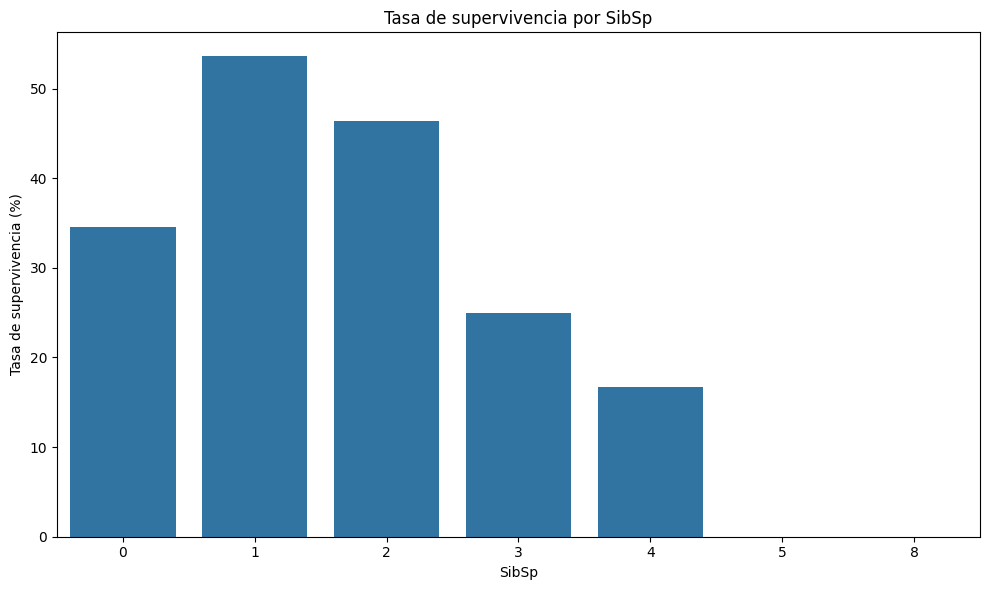

In [32]:
# Tasa de supervivencia basada en SibSp
tasa_sibsp = (
    df.groupby('SibSp')['Survived']
      .mean()
      .mul(100)
      .reset_index(name='TasaSupervivencia')
)

plt.figure(figsize=(10, 6))
sns.barplot(data=tasa_sibsp, x='SibSp', y='TasaSupervivencia')
plt.title('Tasa de supervivencia por SibSp')
plt.xlabel('SibSp')
plt.ylabel('Tasa de supervivencia (%)')
plt.tight_layout()
plt.show()

In [33]:
# Porcentaje de supervivencia para cada valor de SibSp
porcentaje_supervivencia_sibsp = (
    df.groupby('SibSp')['Survived']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='PorcentajeSupervivencia')
)

print('Porcentaje de supervivencia por SibSp:')
display(porcentaje_supervivencia_sibsp)

Porcentaje de supervivencia por SibSp:


,SibSp,PorcentajeSupervivencia
0,0,34.54
1,1,53.59
2,2,46.43
3,3,25.00
4,4,16.67
5,5,0.00
6,8,0.00
